# Data Layer Validation — Visual Check

This notebook **calls the live `wsq_trading` data layer** and produces plots to confirm:

1. `DataLoader` fetches clean OHLCV data from Yahoo Finance
2. `DataValidator` reports no critical failures
3. `DataCleaner` produces gap-free log-returns
4. `FeatureEngineer` adds the expected columns
5. `SPDESimulator` generates rough Heston paths with the correct roughness character

All figures are saved to `../plot_images/` so they can be included in reports.

---

## 0  Setup

In [1]:
import sys
from pathlib import Path

# Make sure the repo root is on sys.path so wsq_trading is importable
REPO_ROOT = Path().resolve().parents[1]   # plotting_programs/ -> plotting/ -> repo root
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PLOT_DIR = Path().resolve().parent / 'plot_images'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root :', REPO_ROOT)
print('Plot output:', PLOT_DIR)

Repo root : C:\Users\jaisa\OneDrive\Documents\GitHub\Rough-Heston-Trading-Model
Plot output: C:\Users\jaisa\OneDrive\Documents\GitHub\Rough-Heston-Trading-Model\plotting\plot_images


In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
print(sys.executable)
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats

from wsq_trading import config
from wsq_trading.data import DataLoader, DataValidator, DataCleaner, SPDESimulator
from wsq_trading.features import FeatureEngineer

# ── Plot style ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE   = sns.color_palette('tab10')
FIG_DPI   = 150
SAVE_DPI  = 200

def savefig(name: str) -> None:
    """Save current figure to plot_images/ and display inline."""
    path = PLOT_DIR / f'{name}.png'
    plt.savefig(path, dpi=SAVE_DPI, bbox_inches='tight')
    print(f'  Saved -> {path.name}')

print('Imports OK  |  matplotlib', matplotlib.__version__, '| pandas', pd.__version__)

c:\Program Files\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Imports OK  |  matplotlib 3.10.3 | pandas 2.2.3


---
## 1  Load Market Data

We fetch OHLCV data for all tickers in `config.TICKERS` using `DataLoader`.  
A parquet cache is written on first run; subsequent runs load from disk instantly.

In [3]:
TICKER_FOCUS = 'ES=F'   # single ticker used for detailed per-chart analysis
START        = '2015-01-01'
END          = None       # today

loader = DataLoader()

# Fetch focused ticker
df_raw = loader.fetch(TICKER_FOCUS, start=START, end=END)
print(f'{TICKER_FOCUS}  |  {len(df_raw):,} rows  |  {df_raw.index[0].date()} -> {df_raw.index[-1].date()}')
df_raw.head()

2026-05-02 16:46:11 | INFO     | wsq_trading.data.data_loader | Downloading 'ES=F' from Yahoo Finance (2015-01-01 → 2026-05-02)…
2026-05-02 16:46:12 | INFO     | wsq_trading.utils | yfinance download [ES=F] finished in 1.13 s.
2026-05-02 16:46:13 | INFO     | wsq_trading.data.data_loader | Cached 'ES=F' → C:\Users\jaisa\OneDrive\Documents\GitHub\Rough-Heston-Trading-Model\data\raw\futures\ES_F.parquet  (2850 rows)


ES=F  |  2,850 rows  |  2015-01-02 -> 2026-05-01


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,2055.00,2067.25,2038.75,2046.25,1358348
2015-01-05,2045.75,2048.25,2009.50,2016.00,2033774
2015-01-06,2019.00,2023.50,1984.25,1994.50,2345361
2015-01-07,1996.50,2023.75,1995.75,2019.50,1760658
2015-01-08,2020.50,2058.50,2020.25,2055.00,1555733


In [4]:
# Fetch all configured tickers
all_data = loader.fetch_all(start=START)
print('Loaded tickers:', list(all_data.keys()))
for t, df in all_data.items():
    print(f'  {t:8s}  {len(df):,} rows  {df.index[0].date()} -> {df.index[-1].date()}')

2026-05-02 16:46:18 | INFO     | wsq_trading.data.data_loader | Loading 'ES=F' from cache: C:\Users\jaisa\OneDrive\Documents\GitHub\Rough-Heston-Trading-Model\data\raw\futures\ES_F.parquet
2026-05-02 16:46:18 | INFO     | wsq_trading.data.data_loader | Downloading 'NQ=F' from Yahoo Finance (2015-01-01 → 2026-05-02)…
2026-05-02 16:46:19 | INFO     | wsq_trading.utils | yfinance download [NQ=F] finished in 0.31 s.
2026-05-02 16:46:19 | INFO     | wsq_trading.data.data_loader | Cached 'NQ=F' → C:\Users\jaisa\OneDrive\Documents\GitHub\Rough-Heston-Trading-Model\data\raw\futures\NQ_F.parquet  (2850 rows)
2026-05-02 16:46:19 | INFO     | wsq_trading.data.data_loader | Downloading 'CL=F' from Yahoo Finance (2015-01-01 → 2026-05-02)…
2026-05-02 16:46:19 | INFO     | wsq_trading.utils | yfinance download [CL=F] finished in 0.37 s.
2026-05-02 16:46:19 | INFO     | wsq_trading.data.data_loader | Cached 'CL=F' → C:\Users\jaisa\OneDrive\Documents\GitHub\Rough-Heston-Trading-Model\data\raw\futures\C

Loaded tickers: ['ES=F', 'NQ=F', 'CL=F', 'GC=F', 'ZB=F']
  ES=F      2,850 rows  2015-01-02 -> 2026-05-01
  NQ=F      2,850 rows  2015-01-02 -> 2026-05-01
  CL=F      2,849 rows  2015-01-02 -> 2026-05-01
  GC=F      2,848 rows  2015-01-02 -> 2026-05-01
  ZB=F      2,849 rows  2015-01-02 -> 2026-05-01


---
## 2  Validate Data

`DataValidator` runs six checks: schema, row count, OHLCV sanity, gaps, future dates, and outliers.

In [5]:
validator = DataValidator()

print('=' * 60)
for ticker, df in all_data.items():
    report = validator.validate(df, ticker=ticker)
    status = 'PASS' if report.passed else 'FAIL'
    print(f'[{status}] {ticker}')
    for r in report.results:
        icon = '  OK ' if r.passed else '  !! '
        msgs = ' | '.join(r.messages) if r.messages else ''
        print(f'{icon}{r.check_name:<22}{msgs}')
    print()

2026-05-02 16:46:24 | INFO     | wsq_trading.data.data_validator | [✓ PASS] ES=F: 6 passed, 0 failed (6 checks total)
2026-05-02 16:46:24 | INFO     | wsq_trading.data.data_validator | [✓ PASS] NQ=F: 6 passed, 0 failed (6 checks total)
2026-05-02 16:46:24 | WARNING  | wsq_trading.data.data_validator | [CL=F] ValidationResult(FAIL | ohlcv_sanity: Close ≤ 0 on 1 rows.)
2026-05-02 16:46:24 | INFO     | wsq_trading.data.data_validator | [✗ FAIL] CL=F: 5 passed, 1 failed (6 checks total)
2026-05-02 16:46:24 | INFO     | wsq_trading.data.data_validator | [✓ PASS] GC=F: 6 passed, 0 failed (6 checks total)
2026-05-02 16:46:24 | INFO     | wsq_trading.data.data_validator | [✓ PASS] ZB=F: 6 passed, 0 failed (6 checks total)


[PASS] ES=F
  OK schema                
  OK min_rows              
  OK ohlcv_sanity          
  OK gaps                  
  OK no_future_dates       
  OK outliers              4 outlier(s) beyond 8.0σ: 2020-03-12 (z=9.3), 2020-03-16 (z=9.8), 2020-03-23 (z=8.3), 2020-03-24 (z=8.3)

[PASS] NQ=F
  OK schema                
  OK min_rows              
  OK ohlcv_sanity          
  OK gaps                  
  OK no_future_dates       
  OK outliers              2 outlier(s) beyond 8.0σ: 2020-03-16 (z=8.3), 2025-04-09 (z=8.0)

[FAIL] CL=F
  OK schema                
  OK min_rows              
  !! ohlcv_sanity          Close ≤ 0 on 1 rows.
  OK gaps                  
  OK no_future_dates       
  OK outliers              4 outlier(s) beyond 8.0σ: 2020-03-09 (z=9.7), 2020-03-18 (z=9.6), 2020-04-22 (z=10.9), 2020-04-27 (z=9.7)

[PASS] GC=F
  OK schema                
  OK min_rows              
  OK ohlcv_sanity          
  OK gaps                  
  OK no_future_dates       
  OK outlier

---
## 3  Clean Data + Feature Engineering

Pass raw OHLCV through `DataCleaner.run_pipeline`, then `FeatureEngineer.run_pipeline`.

In [6]:
cleaner = DataCleaner()
engineer = FeatureEngineer()

processed = {}
for ticker, df in all_data.items():
    clean  = cleaner.run_pipeline(df)
    feats  = engineer.run_pipeline(clean)
    processed[ticker] = feats
    print(f'{ticker:8s}  {len(feats):,} rows  {len(feats.columns)} columns')

df = processed[TICKER_FOCUS]
print('\nColumns:', list(df.columns))

2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline started (2850 rows in).
2026-05-02 16:46:31 | WARNING  | wsq_trading.data.data_cleaner | remove_outliers: replacing 7 outlier row(s) (|z| > 6.0) via linear interpolation.
2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline complete: 2850 → 2944 rows (dropped -94).
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: 2944 rows in.
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: done. 23 columns added.
2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline started (2850 rows in).
2026-05-02 16:46:31 | WARNING  | wsq_trading.data.data_cleaner | remove_outliers: replacing 4 outlier row(s) (|z| > 6.0) via linear interpolation.
2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline complete: 2850 → 2943 rows (dropped -93)

ES=F      2,944 rows  23 columns
NQ=F      2,943 rows  23 columns


2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline complete: 2849 → 2943 rows (dropped -94).
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: 2943 rows in.
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: done. 23 columns added.
2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline started (2848 rows in).
2026-05-02 16:46:31 | WARNING  | wsq_trading.data.data_cleaner | remove_outliers: replacing 2 outlier row(s) (|z| > 6.0) via linear interpolation.
2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline complete: 2848 → 2913 rows (dropped -65).
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: 2913 rows in.
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: done. 23 columns added.
2026-05-

CL=F      2,943 rows  23 columns
GC=F      2,913 rows  23 columns


2026-05-02 16:46:31 | WARNING  | wsq_trading.data.data_cleaner | remove_outliers: replacing 2 outlier row(s) (|z| > 6.0) via linear interpolation.
2026-05-02 16:46:31 | INFO     | wsq_trading.data.data_cleaner | Cleaning pipeline complete: 2849 → 2941 rows (dropped -92).
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: 2941 rows in.
2026-05-02 16:46:31 | INFO     | wsq_trading.features.feature_engineer | FeatureEngineer.run_pipeline: done. 23 columns added.


ZB=F      2,941 rows  23 columns

Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'rv_21d', 'rv_252d', 'vol_ratio', 'ret_mean', 'ret_std', 'ret_skew', 'ret_kurt', 'parkinson_vol', 'volume_ma', 'volume_ratio', 'amihud', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_5', 'ret_lag_10', 'ret_lag_21']


---
## 4  Plots
### 4.1  Price, Volume & Log-Returns — Focus Ticker

ValueError: operands could not be broadcast together with shapes (2944,) (3,) (3,) 

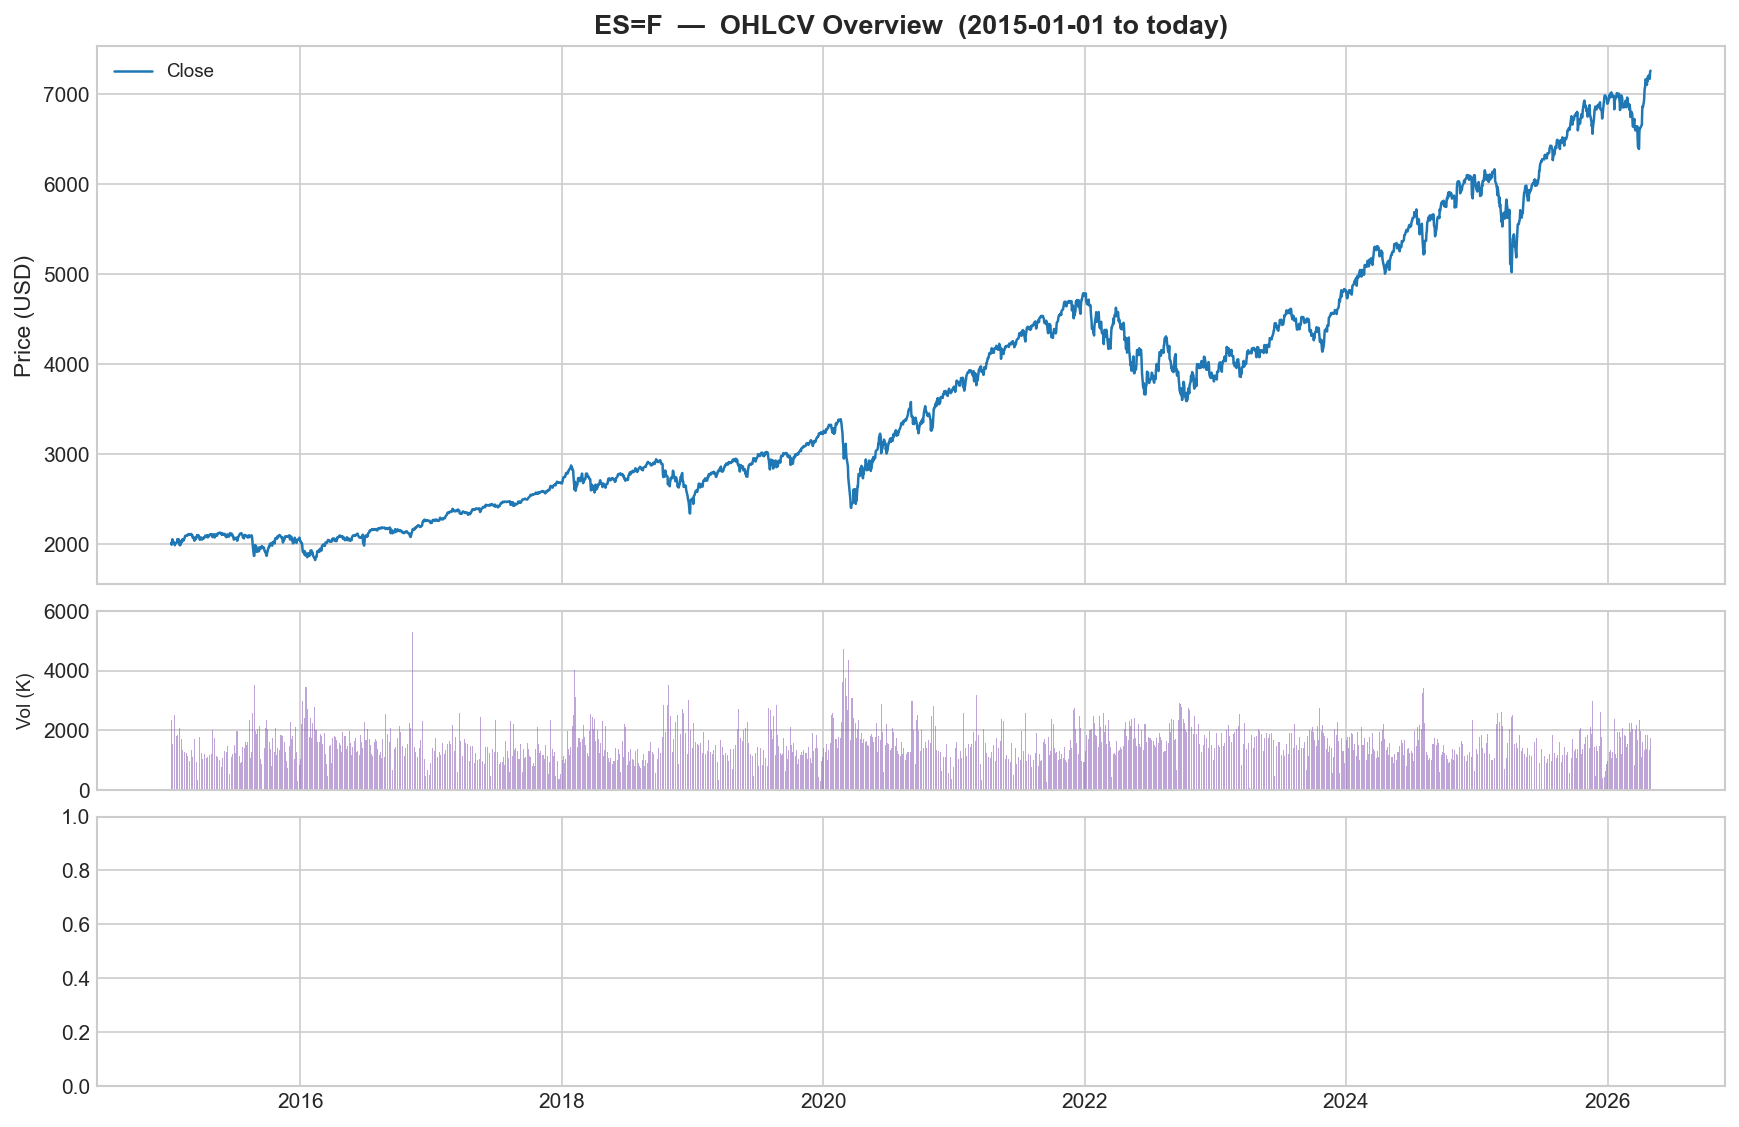

In [7]:
fig = plt.figure(figsize=(14, 9), dpi=FIG_DPI)
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1.5], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# --- Close price ---
ax1.plot(df.index, df['Close'], color=PALETTE[0], lw=1.2, label='Close')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.set_title(f'{TICKER_FOCUS}  —  OHLCV Overview  ({START} to today)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
plt.setp(ax1.get_xticklabels(), visible=False)

# --- Volume ---
ax2.bar(df.index, df['Volume'] / 1e3, color=PALETTE[4], alpha=0.6, width=1)
ax2.set_ylabel('Vol (K)', fontsize=9)
plt.setp(ax2.get_xticklabels(), visible=False)

# --- Log returns ---
ret = df['log_return'].fillna(0)
ax3.bar(df.index, ret * 100, color=np.where(ret >= 0, PALETTE[2], PALETTE[3]), alpha=0.7, width=1)
ax3.axhline(0, color='black', lw=0.6)
ax3.set_ylabel('Log-ret (%)', fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
savefig('01_price_volume_returns')
plt.show()

### 4.2  Normalised Price Comparison — All Tickers

  Saved -> 02_normalised_prices.png


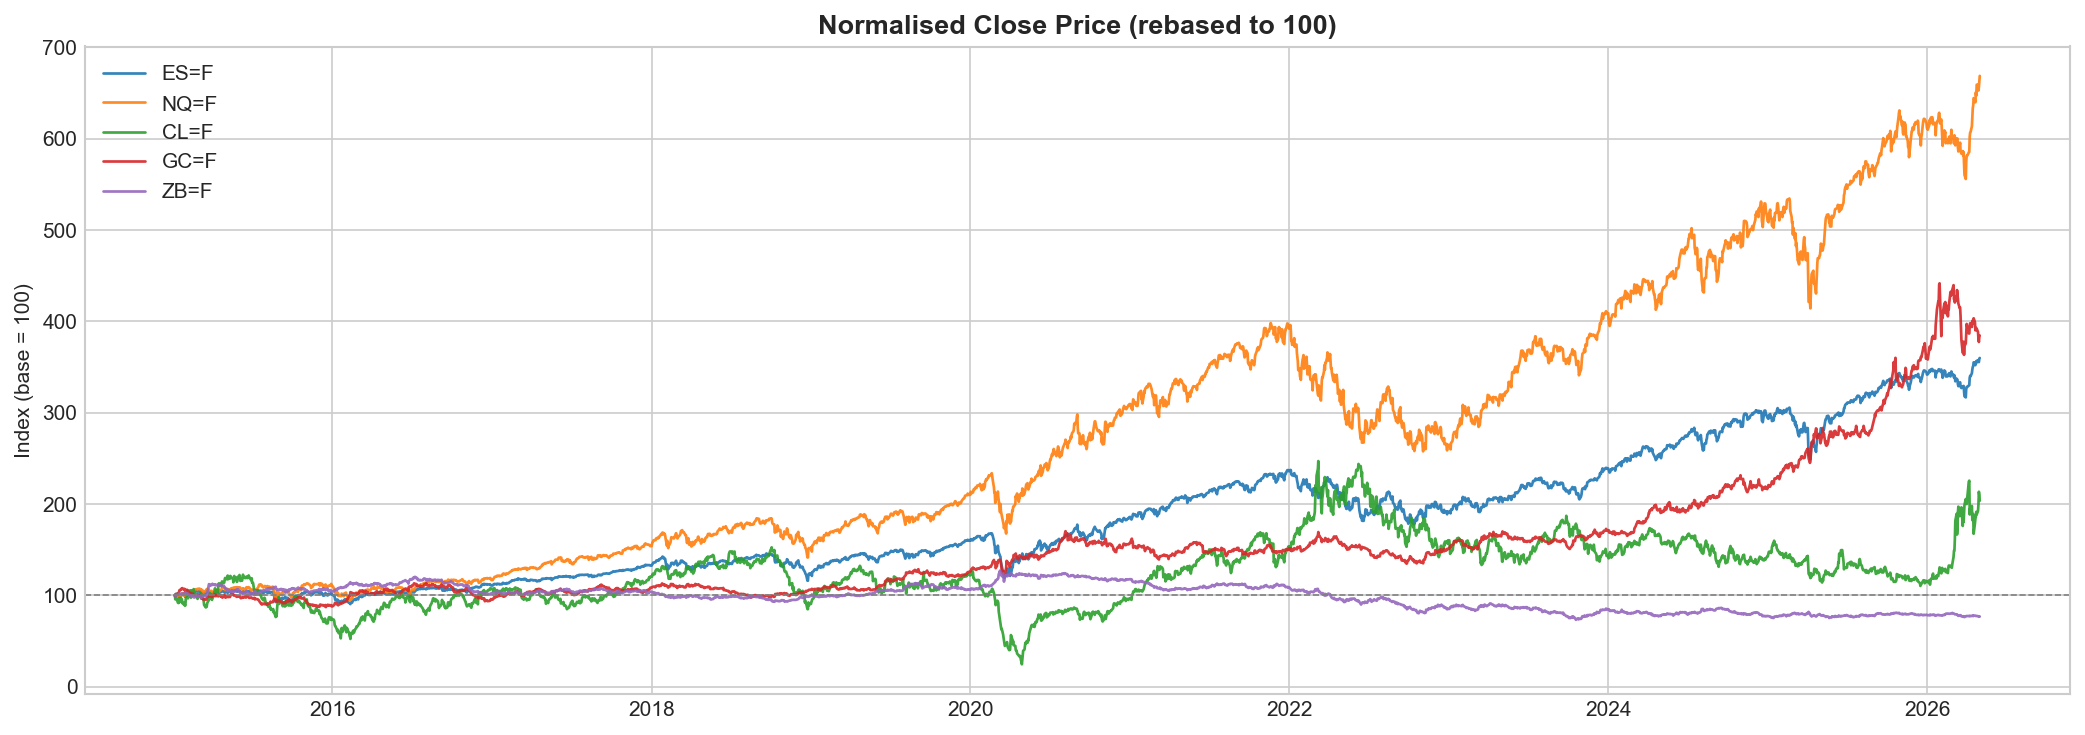

In [8]:
fig, ax = plt.subplots(figsize=(14, 5), dpi=FIG_DPI)

for i, (ticker, df_t) in enumerate(processed.items()):
    norm = df_t['Close'] / df_t['Close'].iloc[0] * 100
    ax.plot(df_t.index, norm, label=ticker, color=PALETTE[i], lw=1.3, alpha=0.9)

ax.axhline(100, color='grey', lw=0.8, ls='--')
ax.set_title('Normalised Close Price (rebased to 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Index (base = 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)

plt.tight_layout()
savefig('02_normalised_prices')
plt.show()

### 4.3  Daily Log-Return Distributions — All Tickers

  Saved -> 03_return_distributions.png


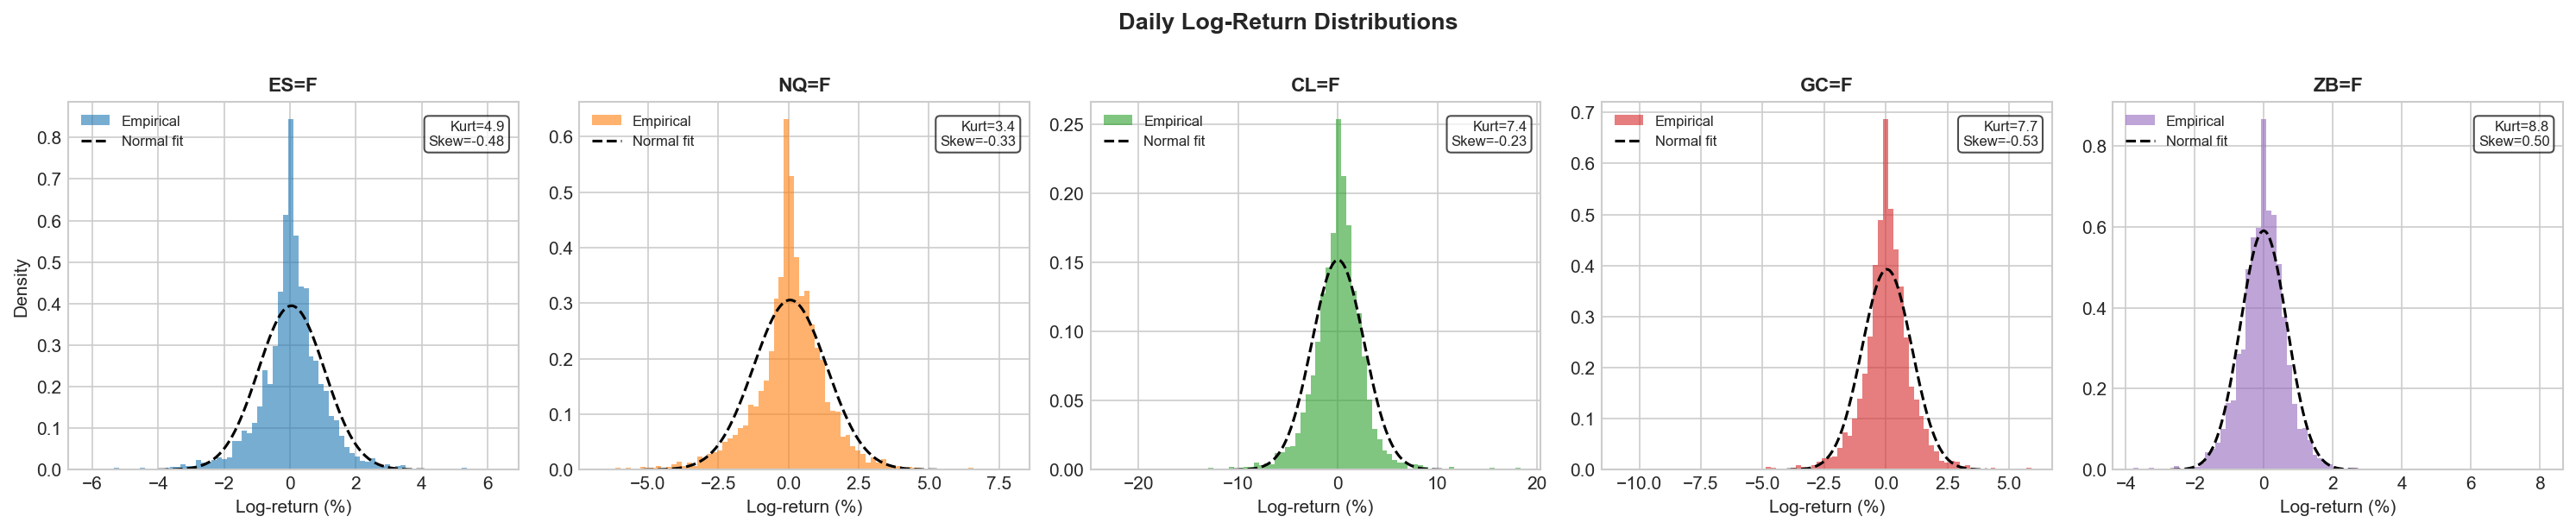

In [9]:
n_tickers = len(processed)
fig, axes = plt.subplots(1, n_tickers, figsize=(4 * n_tickers, 4), dpi=FIG_DPI, sharey=False)
if n_tickers == 1:
    axes = [axes]

for i, (ticker, df_t) in enumerate(processed.items()):
    ax  = axes[i]
    ret = df_t['log_return'].dropna()

    ax.hist(ret * 100, bins=80, density=True, color=PALETTE[i], alpha=0.6, label='Empirical')

    # Fitted normal overlay
    mu, sigma = ret.mean() * 100, ret.std() * 100
    xs = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color='black', lw=1.5, ls='--', label='Normal fit')

    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.set_xlabel('Log-return (%)')
    if i == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    kurt = ret.kurt()
    ax.text(0.97, 0.95, f'Kurt={kurt:.1f}\nSkew={ret.skew():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('Daily Log-Return Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('03_return_distributions')
plt.show()

### 4.4  Realized Volatility — All Tickers

  Saved -> 04_realized_volatility.png


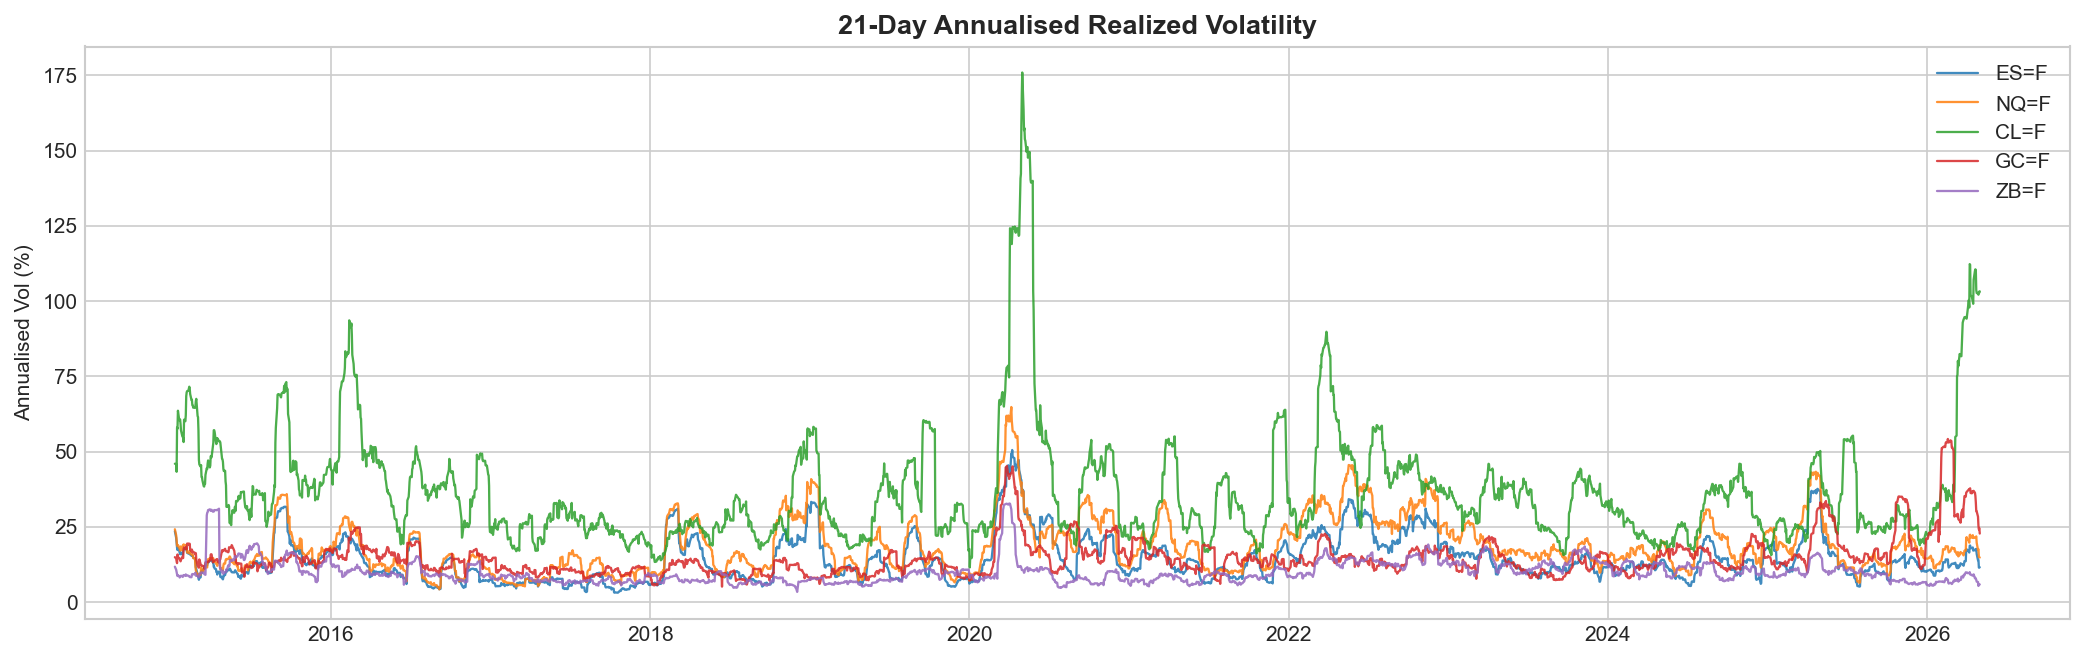

In [10]:
vol_col = f'rv_{engineer._vol_window}d'

fig, ax = plt.subplots(figsize=(14, 4.5), dpi=FIG_DPI)

for i, (ticker, df_t) in enumerate(processed.items()):
    if vol_col in df_t.columns:
        ax.plot(df_t.index, df_t[vol_col] * 100, label=ticker,
                color=PALETTE[i], lw=1.1, alpha=0.85)

ax.set_title(f'{engineer._vol_window}-Day Annualised Realized Volatility', fontsize=13, fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)

plt.tight_layout()
savefig('04_realized_volatility')
plt.show()

### 4.5  Rolling Return Statistics — Focus Ticker

  Saved -> 05_rolling_statistics.png


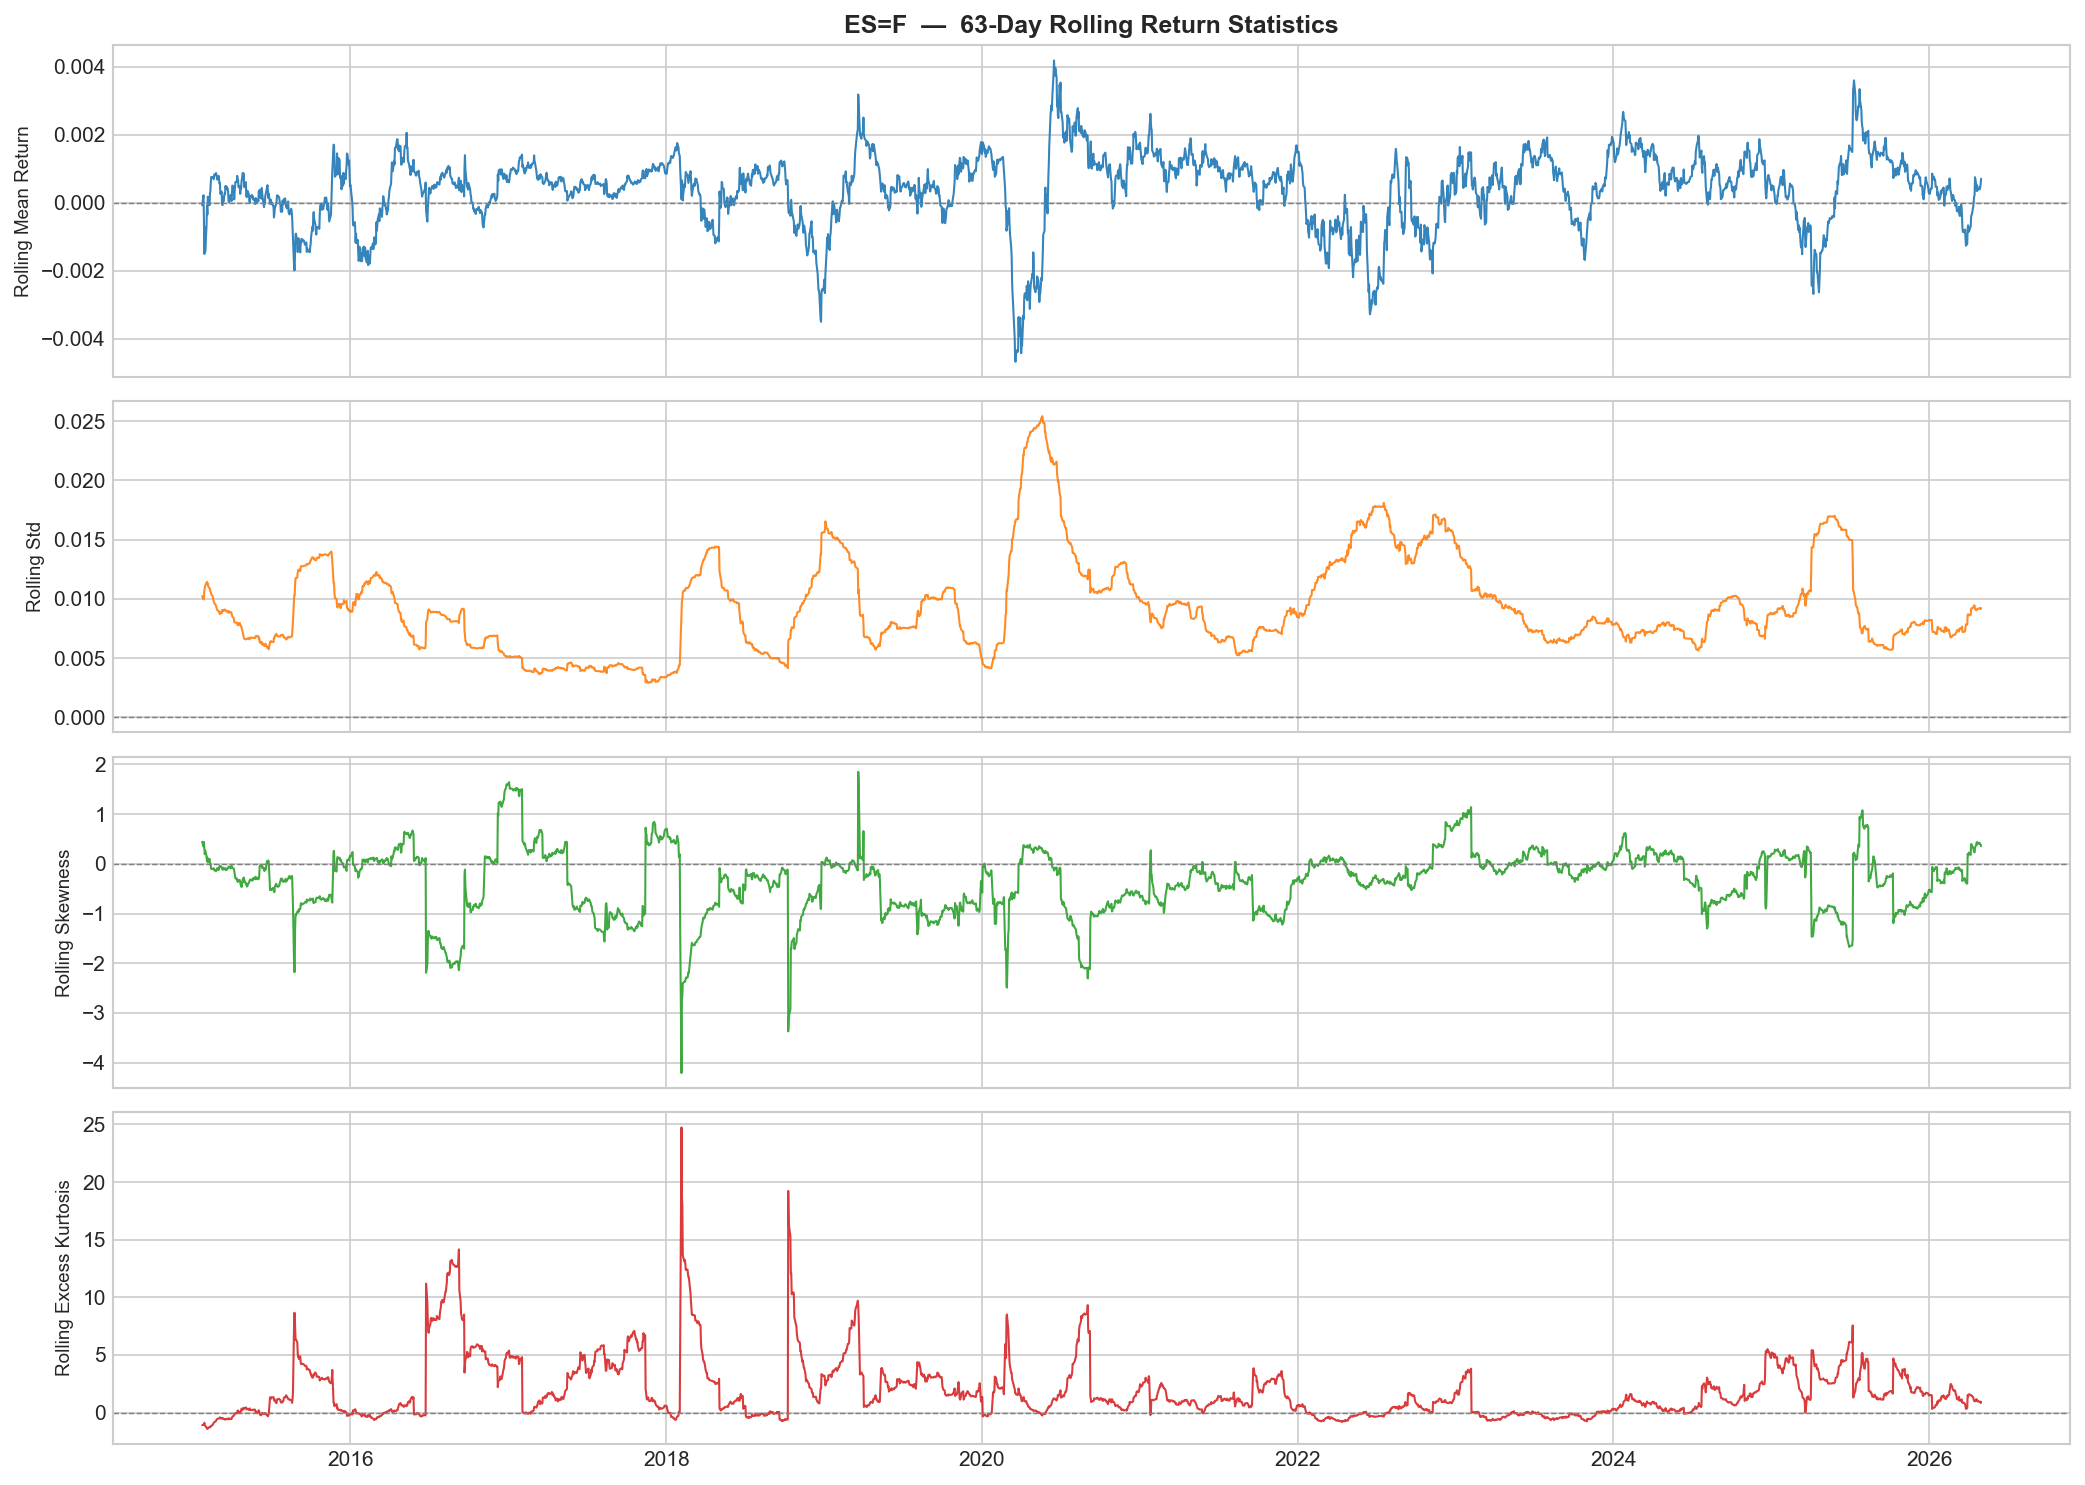

In [11]:
df_focus = processed[TICKER_FOCUS]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), dpi=FIG_DPI, sharex=True)
metrics = [
    ('ret_mean',  'Rolling Mean Return',    PALETTE[0]),
    ('ret_std',   'Rolling Std',            PALETTE[1]),
    ('ret_skew',  'Rolling Skewness',       PALETTE[2]),
    ('ret_kurt',  'Rolling Excess Kurtosis',PALETTE[3]),
]

for ax, (col, title, color) in zip(axes, metrics):
    if col not in df_focus.columns:
        ax.set_visible(False)
        continue
    ax.plot(df_focus.index, df_focus[col], color=color, lw=1, alpha=0.9)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_ylabel(title, fontsize=9)

axes[0].set_title(
    f'{TICKER_FOCUS}  —  {engineer._stats_window}-Day Rolling Return Statistics',
    fontsize=12, fontweight='bold'
)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
savefig('05_rolling_statistics')
plt.show()

### 4.6  Feature Correlation Matrix — Focus Ticker

  Saved -> 06_feature_correlation.png


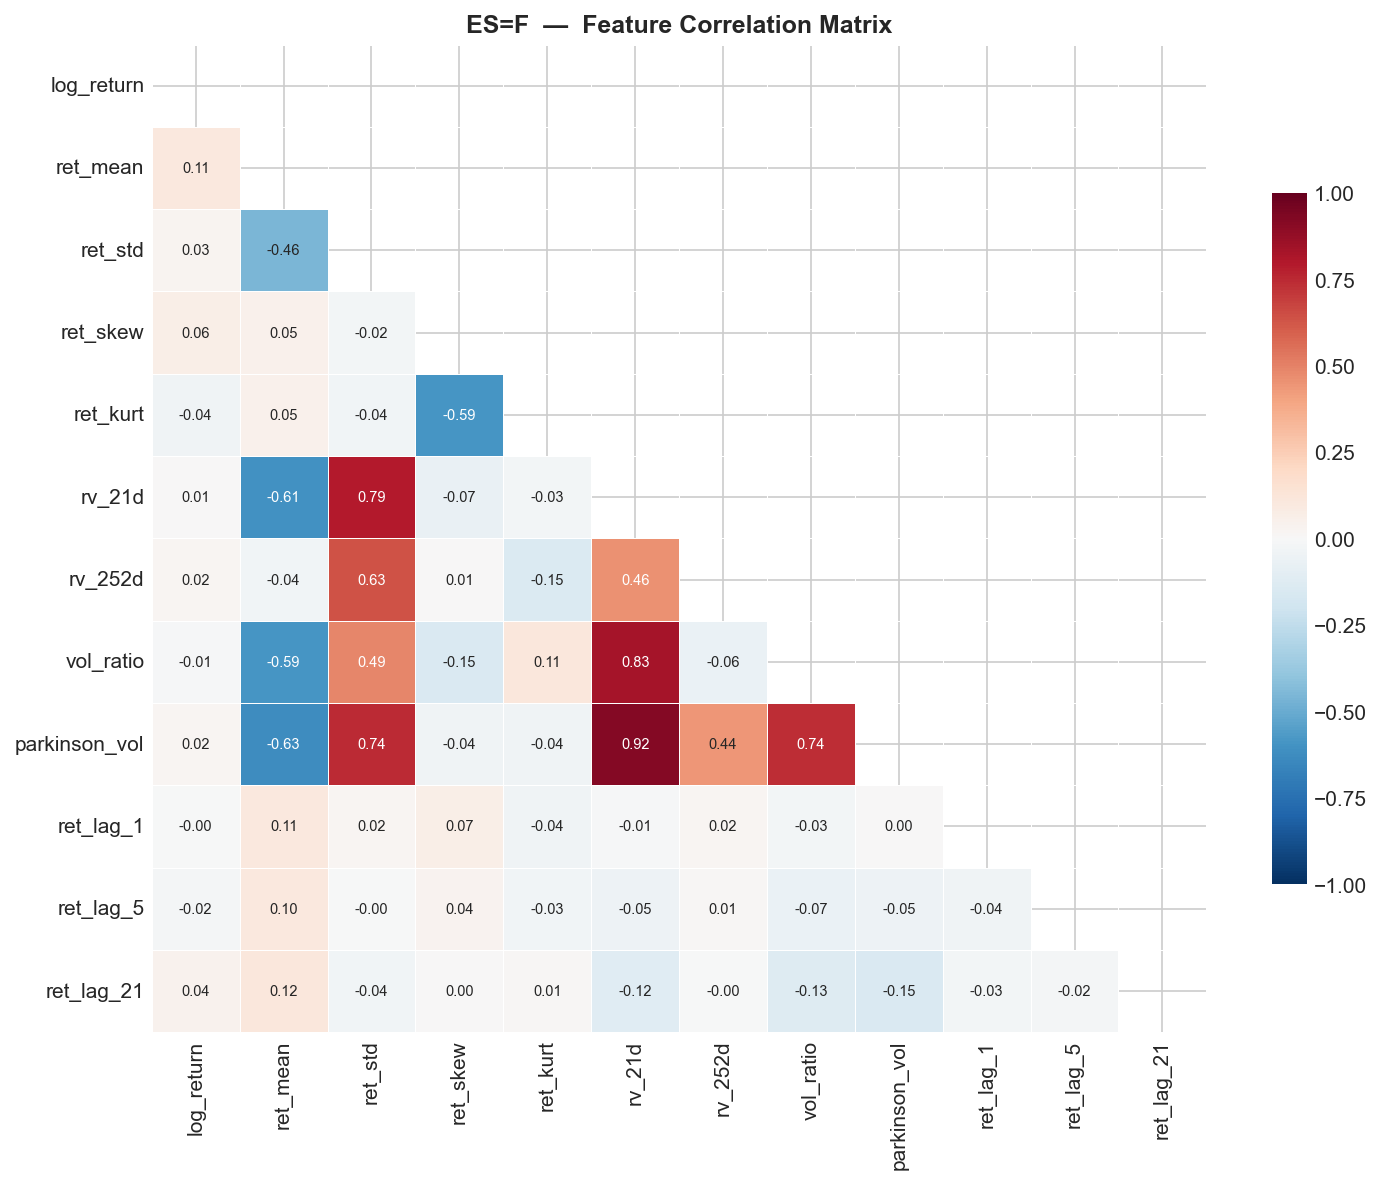

In [12]:
feature_cols = [
    'log_return', 'ret_mean', 'ret_std', 'ret_skew', 'ret_kurt',
    f'rv_{engineer._vol_window}d', f'rv_{engineer._long_window}d',
    'vol_ratio', 'parkinson_vol',
    'ret_lag_1', 'ret_lag_5', 'ret_lag_21',
]
feature_cols = [c for c in feature_cols if c in df_focus.columns]

corr = df_focus[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), dpi=FIG_DPI)
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, cbar_kws={'shrink': 0.7},
)
ax.set_title(f'{TICKER_FOCUS}  —  Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('06_feature_correlation')
plt.show()

---
## 5  SPDE Simulator Validation
### 5.1  Sample Rough Heston Price Paths by H

In [13]:
HURST_DEMO  = [0.10, 0.20, 0.30, 0.40]   # subset of H values to visualise
N_DEMO_PATHS = 5                           # paths per H

sim = SPDESimulator(
    T=252,
    n_paths_per_hurst=N_DEMO_PATHS,
    hurst_grid=HURST_DEMO,
    num_workers=1,
)

# Generate a batch for each H and reconstruct price index from returns
spde_paths = {}
for H in HURST_DEMO:
    df_batch = sim.simulate_batch(H=H, n_paths=N_DEMO_PATHS)
    spde_paths[H] = df_batch

print('SPDE paths generated for H =', HURST_DEMO)

SPDE paths generated for H = [0.1, 0.2, 0.3, 0.4]


  Saved -> 07_spde_price_paths.png


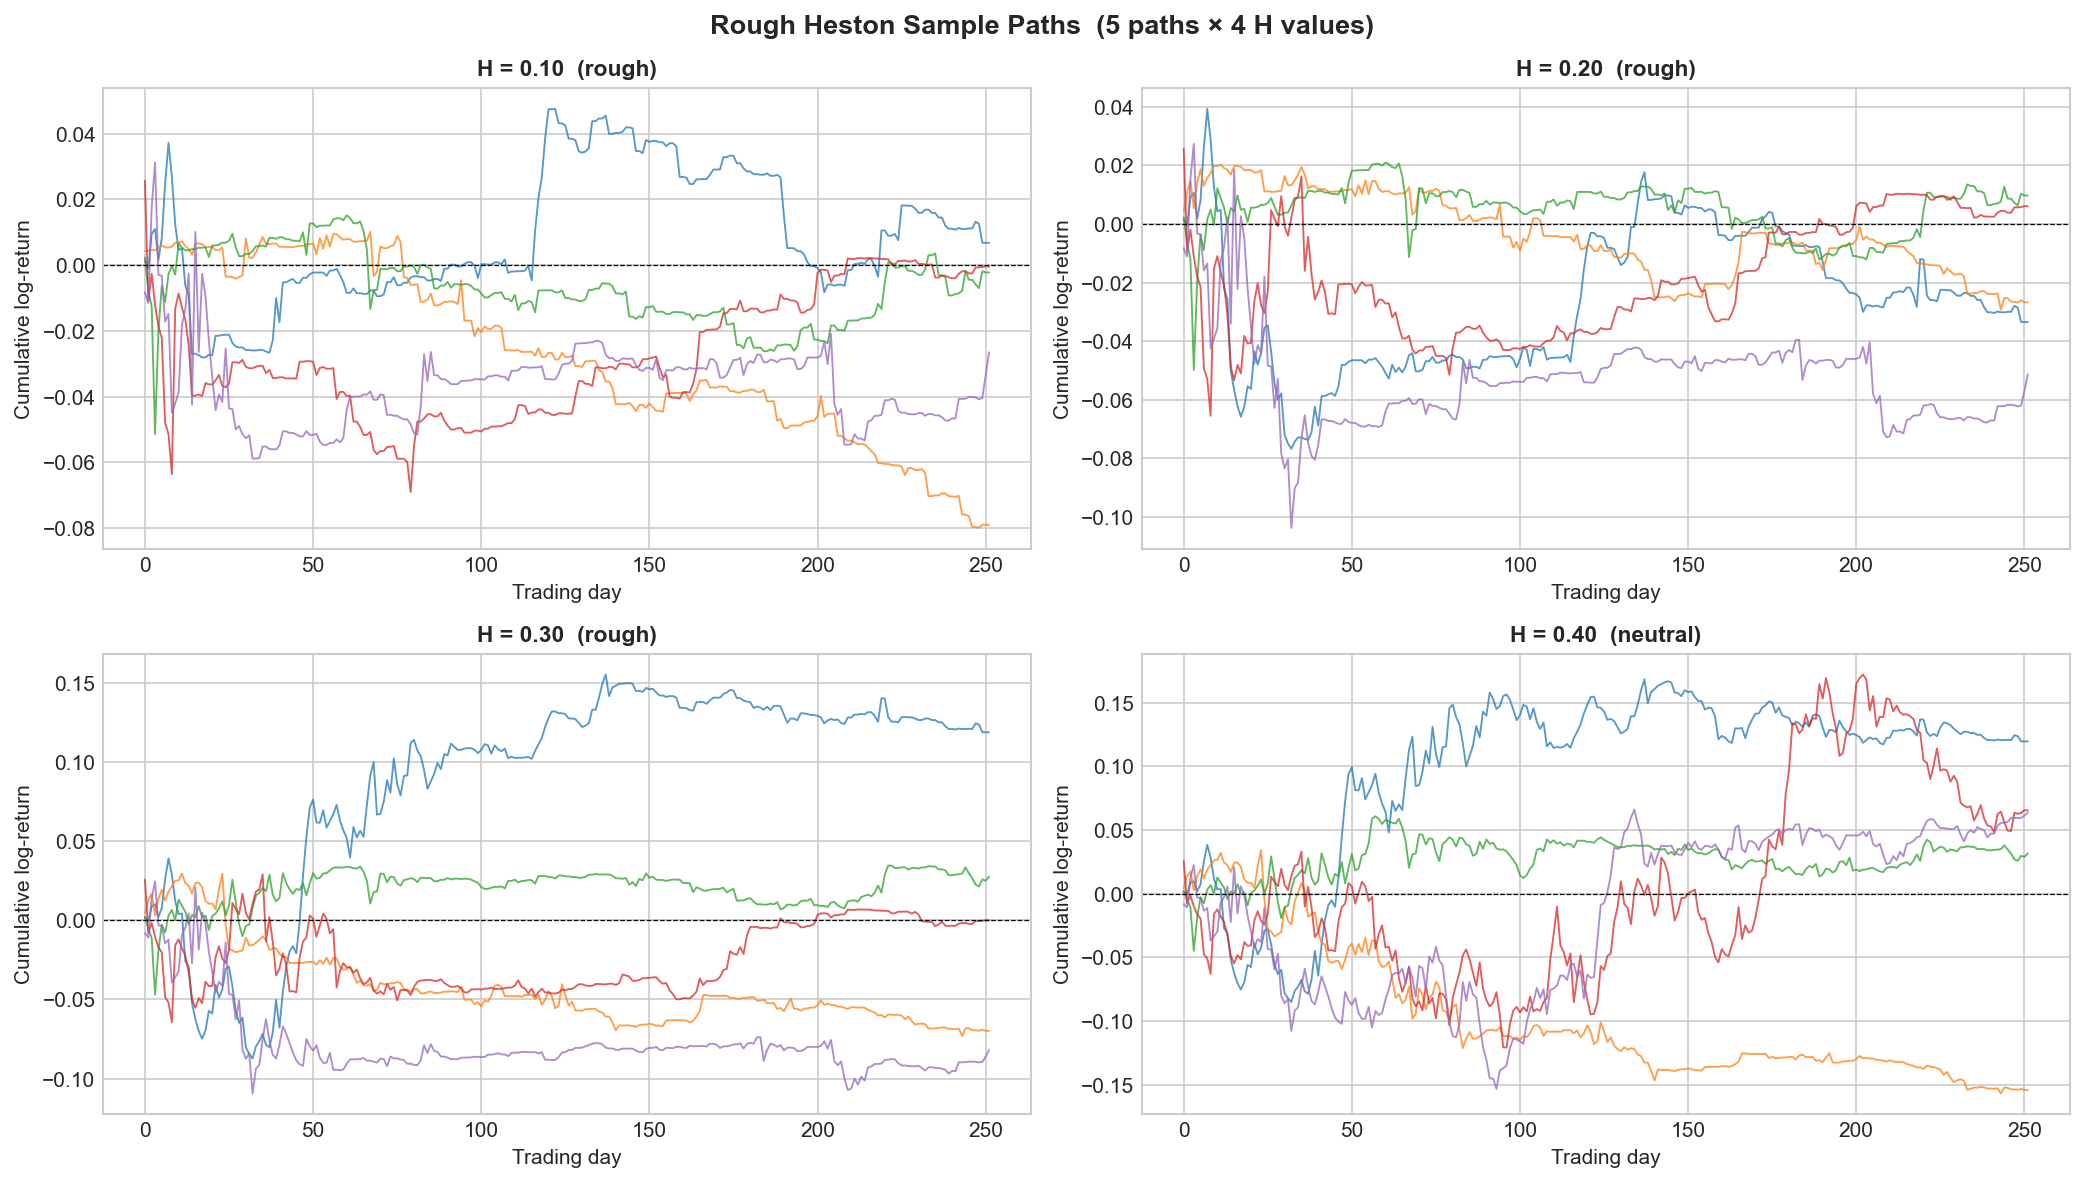

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=FIG_DPI)

for ax, H in zip(axes.flat, HURST_DEMO):
    df_h = spde_paths[H]

    for path_id in df_h['path_id'].unique():
        path = df_h[df_h['path_id'] == path_id].sort_values('step')
        # Reconstruct log-price index (start at 0)
        log_price = path['log_return'].cumsum().values
        ax.plot(log_price, lw=0.9, alpha=0.75)

    ax.set_title(f'H = {H:.2f}  ({"rough" if H < 0.35 else "neutral" if H <= 0.65 else "trending"})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Trading day')
    ax.set_ylabel('Cumulative log-return')
    ax.axhline(0, color='black', lw=0.6, ls='--')

fig.suptitle(
    f'Rough Heston Sample Paths  ({N_DEMO_PATHS} paths × 4 H values)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
savefig('07_spde_price_paths')
plt.show()

### 5.2  Variance Process Comparison by H

  Saved -> 08_spde_variance_paths.png


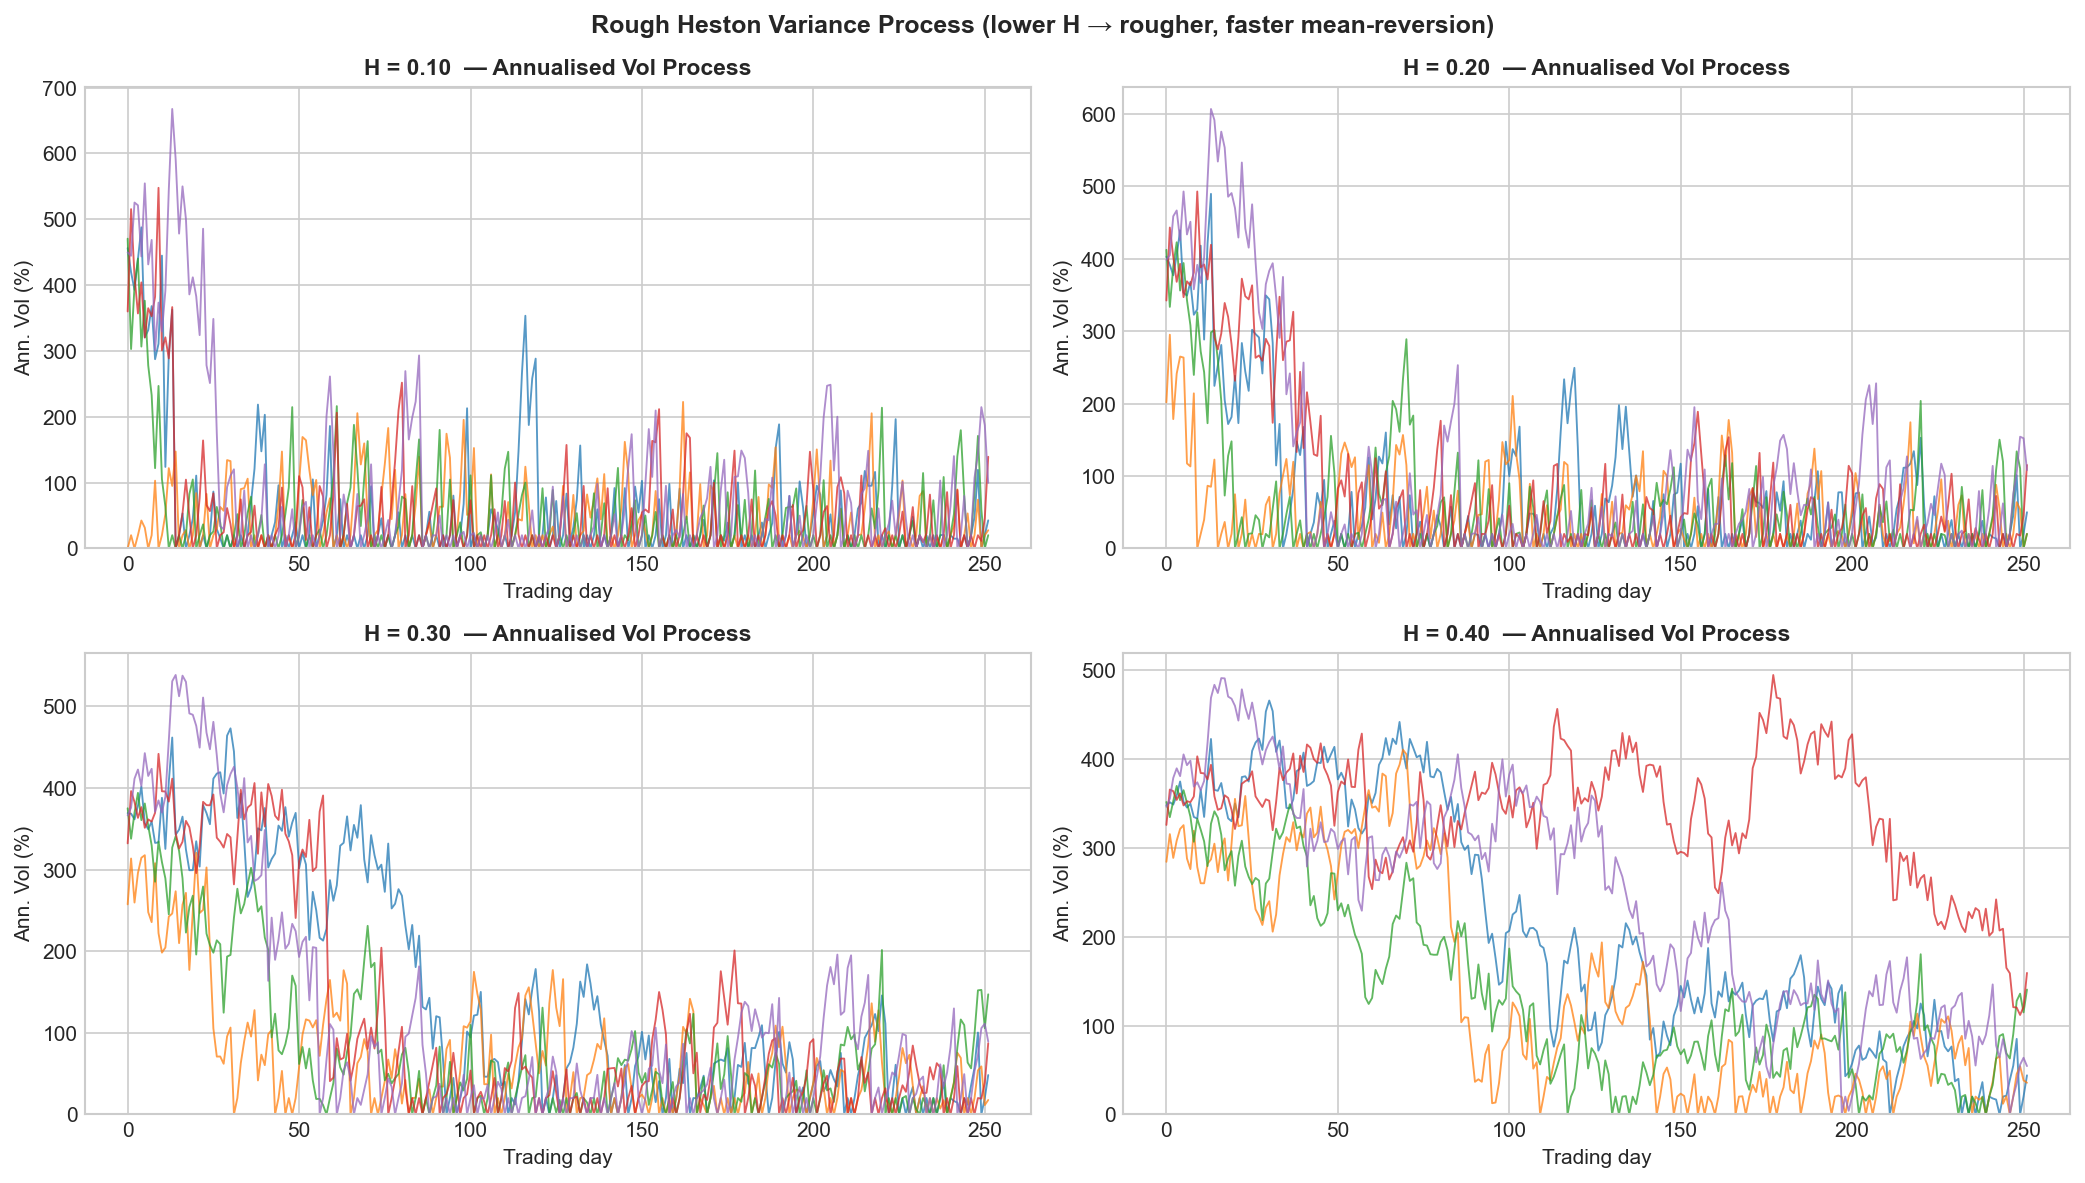

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=FIG_DPI)

for ax, H in zip(axes.flat, HURST_DEMO):
    df_h = spde_paths[H]

    for path_id in df_h['path_id'].unique():
        path = df_h[df_h['path_id'] == path_id].sort_values('step')
        vol  = np.sqrt(path['variance'].values) * np.sqrt(252) * 100   # annualised %
        ax.plot(vol, lw=0.9, alpha=0.75)

    ax.set_title(f'H = {H:.2f}  — Annualised Vol Process', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trading day')
    ax.set_ylabel('Ann. Vol (%)')
    ax.set_ylim(bottom=0)

fig.suptitle('Rough Heston Variance Process (lower H → rougher, faster mean-reversion)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('08_spde_variance_paths')
plt.show()

### 5.3  Return Distribution by H — Rough vs Persistent

  Saved -> 09_spde_return_distributions.png


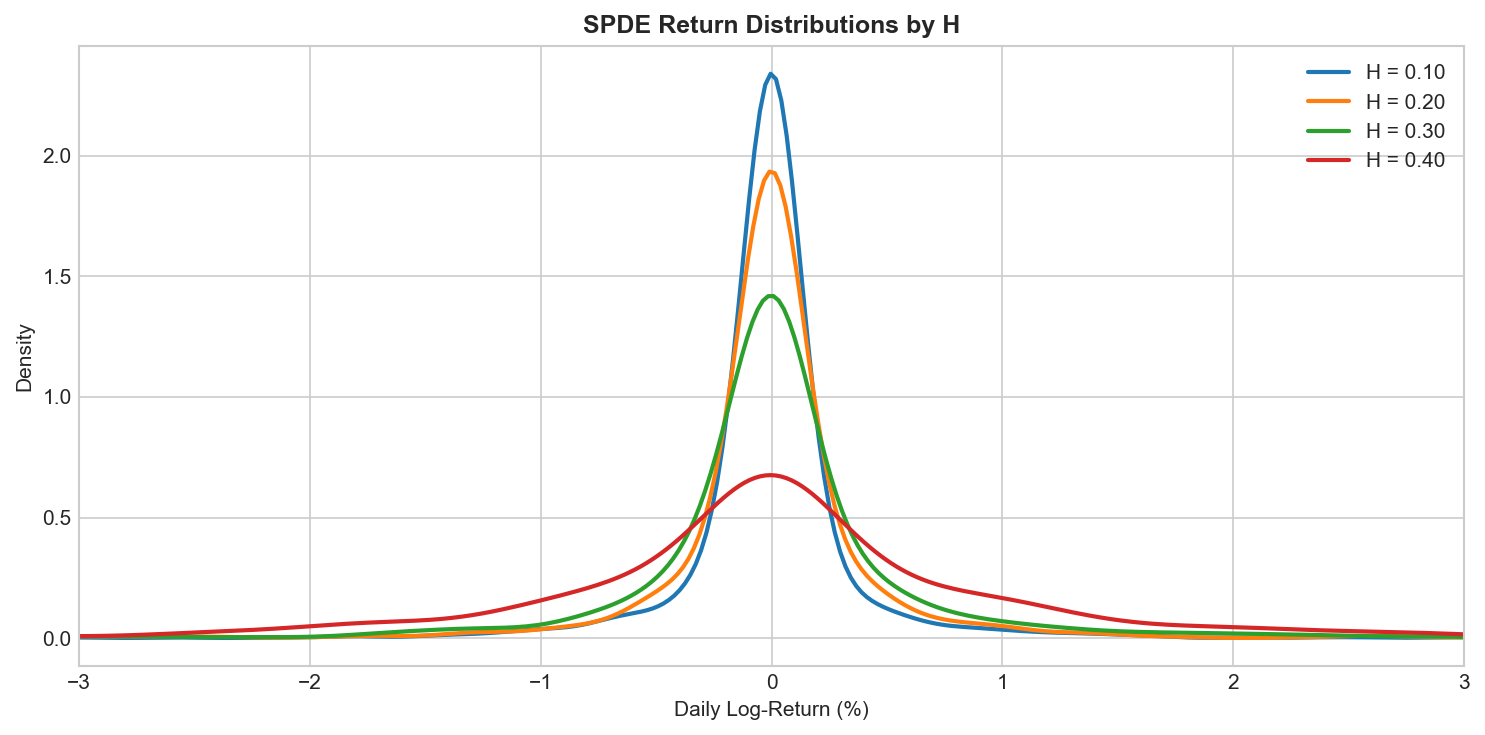

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=FIG_DPI)

for i, H in enumerate(HURST_DEMO):
    df_h  = spde_paths[H]
    rets  = df_h['log_return'].values * 100
    kde_x = np.linspace(rets.min(), rets.max(), 400)
    kde   = stats.gaussian_kde(rets)
    ax.plot(kde_x, kde(kde_x), lw=2, label=f'H = {H:.2f}', color=PALETTE[i])

ax.set_xlabel('Daily Log-Return (%)')
ax.set_ylabel('Density')
ax.set_title('SPDE Return Distributions by H', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-3, 3)

plt.tight_layout()
savefig('09_spde_return_distributions')
plt.show()

### 5.4  Autocorrelation of |Returns| by H

Lower H produces faster-decaying autocorrelation (rougher, more anti-persistent).  
Higher H shows slower decay (more persistent).

  Saved -> 10_spde_acf_abs_returns.png


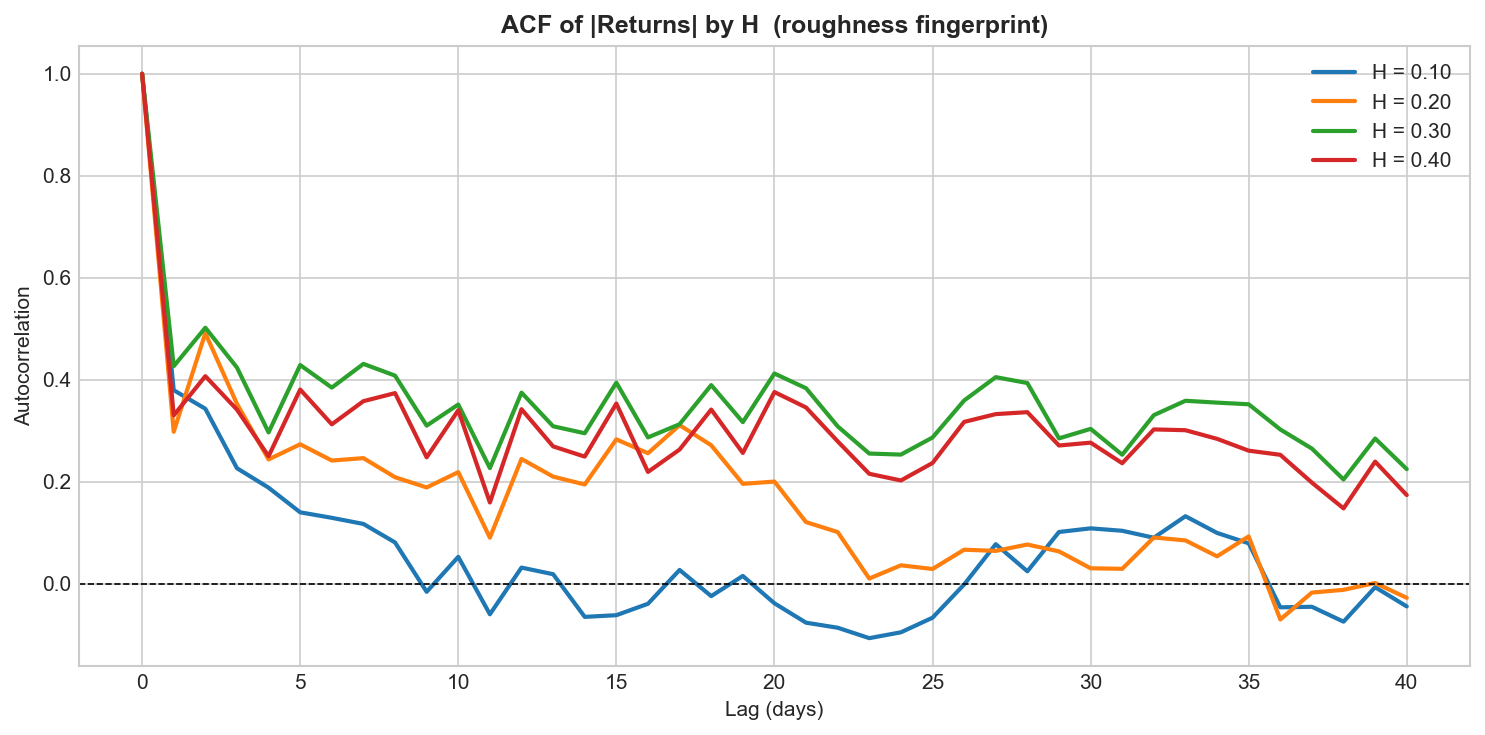

In [17]:
MAX_LAG = 40

fig, ax = plt.subplots(figsize=(10, 5), dpi=FIG_DPI)

for i, H in enumerate(HURST_DEMO):
    df_h  = spde_paths[H]
    rets  = df_h.groupby('path_id')['log_return'].apply(list).iloc[0]
    abs_r = np.abs(rets)
    acf   = [np.corrcoef(abs_r[:-lag], abs_r[lag:])[0, 1] if lag > 0 else 1.0
             for lag in range(MAX_LAG + 1)]
    ax.plot(range(MAX_LAG + 1), acf, lw=2, label=f'H = {H:.2f}', color=PALETTE[i])

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of |Returns| by H  (roughness fingerprint)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
savefig('10_spde_acf_abs_returns')
plt.show()

---
## 6  Summary

| # | Plot file | What it validates |
|---|-----------|-------------------|
| 01 | `01_price_volume_returns.png` | DataLoader returns clean OHLCV; log-returns computed |
| 02 | `02_normalised_prices.png` | All tickers load and align correctly |
| 03 | `03_return_distributions.png` | Return distributions look reasonable (fat tails) |
| 04 | `04_realized_volatility.png` | Realized vol responds to market events (e.g. 2020) |
| 05 | `05_rolling_statistics.png` | Rolling stats pipeline outputs sensible values |
| 06 | `06_feature_correlation.png` | Feature engineering produces interpretable correlations |
| 07 | `07_spde_price_paths.png` | SPDE simulator generates distinct path characters per H |
| 08 | `08_spde_variance_paths.png` | Variance process is non-negative and mean-reverts |
| 09 | `09_spde_return_distributions.png` | Return distributions differ by H as expected |
| 10 | `10_spde_acf_abs_returns.png` | ACF decays faster for lower H (roughness confirmed) |

If all plots look sensible, the data layer is working correctly and Phase 2 (classical Hurst baselines) can begin.